#SpatialzOSM example for the city of Granada, Spain

This notebook describes how to use SpatialzOSM, using Granada (Spain) as an example

First, we install the necessary packages.
SpatialzOSM requires OSMnx, so we isntall it

In [1]:
!pip install OSMnx
!pip install gdal geopandas matplotlib networkx numpy pandas rasterio requests scipy shapely python==3.11.*
!pip install git+https://github.com/bladitoaza/spatialzosm.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.2 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement python==3.11.* (from versions: none)
ERROR: No matching distribution found for python==3.11.*
  Cloning https://github.com/bladitoaza/spatialzosm.git to /tmp/pip-req-build-wv77yk0k
  Running command git clone --filter=blob:none --quiet https://github.com/bladitoaza/spatialzosm.git /tmp/pip-req-build-wv77yk0k
  Resolved https://github.com/bladitoaza/spatialzosm.git to commit a17a28b43460d5ceddd5c488d8e63cf28d4bfe57
  Preparing metadata (setup.py) ... done
  Created wheel for spatialzosm: filename=spatialzosm-0.1-py3-none-any.whl size=11288 sha256=91f5d6df7f70c4db25b0e63bdf1619e7ae83ccc82a80ebf738b8e5f3bbe000c8
  Stored in directory: /tmp/pip-ephem-wheel-cache-bpbmyxpc/wheels/2c/cd/ba/4e435e2c41f0a11f4878c202d21ec2291032725b9e08bb3fae
Successfully built spatialzosm


# Extracting points of interests

Now, we import the necessary packages:
spatialzosm
and data: spatialzOSM-examples

In [2]:
import sys
import geopandas as gpd
from spatialzosm.spatialize import Osmpoi
import os
if not os.path.exists('/content/spatialzOSM-examples'):
  !git clone https://github.com/bladitoaza/spatialzOSM-examples
  print("Github data cloned")

Cloning into 'spatialzOSM-examples'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 106 (delta 33), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 9.30 MiB | 5.63 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Github data cloned


Create an object of the class Osmpoi and initialize the parameters of the object

In [3]:
granada = Osmpoi({
    "city": "Granada",
    "country": "Spain",
})
granada.file_export='Granada_POIs'
granada.save_raw=True

You can extract the points of interest using `fetch_osm_points()`. A raw dataset of the points of interest will be retrieved

In [4]:
granada_pois = granada.fetch_osm_points()

Obtaining POIs from OSM for {'city': 'Granada', 'country': 'Spain'}. It can take a few minutes...
Raw OSM POIs obtained successfully. File saved as Granada_POIs_raw.csv


The raw dataset can be cleaned and automatically filtered using `filter_osm_points() `

In [5]:
osmdata = granada.filter_osm_points(granada_pois)

Filtering, cleaning and rearranging POIs for {'city': 'Granada', 'country': 'Spain'}.
 It can take a few minutes...
OSM POIs cleaned successfully. File saved as Granada_POIs_clean.csv


Now we have a dataset of the points of interest in Halifax

# Generating home locations

We read the [geospatial dataset about Granada](https://centrodedescargas.cnig.es/CentroDescargas/limites-municipales-provinciales-autonomicos) containing the information of its zone units (ZUs), which in this case are called [**secciones censales (census section)**](https://www.ine.es/ss/Satellite?L=es_ES&c=Page&cid=1259952026632&p=1259952026632&pagename=ProductosYServicios%2FPYSLayout) of each ZU with their respective [population counts](https://www.granada.org/intranet/idegeogr.nsf/v/tabla-ine-censo-2021). The input dataset is **secciones_censales_Granada_2021_pop.gpkg**

In [6]:
gdf = gpd.read_file('/content/spatialzOSM-examples/Granada/input_data/secciones_censales_Granada_2021_pop.gpkg',
                    crs='EPSG:4326')
gdf.head()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(


,CUSEC,CUMUN,CUDIS,NPRO,NCA,NMUN,Censo_2021_poblacion_Ambos sexos,Censo_2021_poblacion_Hombre,Censo_2021_poblacion_Mujer,geometry
0,1808701001,18087,1808701,Granada,Andalucía,Granada,"1,226",551,675,"MULTIPOLYGON (((446946.686 4114758.262, 446889..."
1,1808701004,18087,1808701,Granada,Andalucía,Granada,"1,226",529,697,"MULTIPOLYGON (((446685.922 4114304.955, 446696..."
2,1808701005,18087,1808701,Granada,Andalucía,Granada,"1,186",546,640,"MULTIPOLYGON (((446543.185 4114589.994, 446556..."
3,1808701006,18087,1808701,Granada,Andalucía,Granada,"1,410",582,828,"MULTIPOLYGON (((446466.733 4114328.595, 446488..."
4,1808701007,18087,1808701,Granada,Andalucía,Granada,"1,381",635,746,"MULTIPOLYGON (((446329.436 4114596.538, 446331..."


We rename the columns by giving an appropriate name

In [7]:
new_ind = 'AZ'
gdf.rename(columns={'Censo_2021_poblacion_Ambos sexos':'pop','CUSEC':new_ind}, inplace=True)
gdf.set_index('AZ',inplace = True)
gdf['pop'] = gdf['pop'].str.replace(',', '').astype(int)
gdf.head()

,CUMUN,CUDIS,NPRO,NCA,NMUN,pop,Censo_2021_poblacion_Hombre,Censo_2021_poblacion_Mujer,geometry
AZ,,,,,,,,,
1808701001,18087,1808701,Granada,Andalucía,Granada,1226,551,675,"MULTIPOLYGON (((446946.686 4114758.262, 446889..."
1808701004,18087,1808701,Granada,Andalucía,Granada,1226,529,697,"MULTIPOLYGON (((446685.922 4114304.955, 446696..."
1808701005,18087,1808701,Granada,Andalucía,Granada,1186,546,640,"MULTIPOLYGON (((446543.185 4114589.994, 446556..."
1808701006,18087,1808701,Granada,Andalucía,Granada,1410,582,828,"MULTIPOLYGON (((446466.733 4114328.595, 446488..."
1808701007,18087,1808701,Granada,Andalucía,Granada,1381,635,746,"MULTIPOLYGON (((446329.436 4114596.538, 446331..."


## Generating locations over the zone units

We generate the locations across the areas of the ZUs uniformly

We also evaluate the computation time for 10 runs

In [8]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POIs_area_uniform= granada.create_houses_areas(gdf,method='uniform',pop_size=gdf['pop'].values,crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 1 completed in 4.0333 seconds.

Run 2/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 2 completed in 3.0723 seconds.

Run 3/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 3 completed in 3.0530 seconds.

Run 4/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 4 completed in 3.0243 seconds.

Run 5/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 5 completed in 4.2841 seconds.

Run 6/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 6 completed in 3.0226 seconds.

Run 7/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method uniform
Run 7 completed in 3.1459 seconds.

Run 8/10...


We can also generate the locations across the areas of the ZUs using a normal distribution around a center point. The center points are the centroids of the ZUs shapes

In [9]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POIs_area_normal= granada.create_houses_areas(gdf,method='normal',pop_size=gdf['pop'].values,crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 1 completed in 3.2823 seconds.

Run 2/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 2 completed in 4.1766 seconds.

Run 3/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 3 completed in 3.5574 seconds.

Run 4/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 4 completed in 3.3979 seconds.

Run 5/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 5 completed in 3.0349 seconds.

Run 6/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 6 completed in 4.2653 seconds.

Run 7/10...
Sampling points on areas...
Sampling completed. Coordinates saved to disk for method normal
Run 7 completed in 3.2577 seconds.

Run 8/10...
Samplin

## Generating home locations along the street network

To generate home locations along the road network, we need the geospatial information of the road network.
We can extract the road network from OSM using:

In [10]:
street_network = granada.fetch_osm_streets()

Obtaining street network from OSM for {'city': 'Granada', 'country': 'Spain'}. It can take a few minutes...
OSM streets obtained successfully. File saved as Granada_POIs_streets.csv


The datafile is saved or stored as a variable

Next, we load the extracted road network from file

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


<Axes: >

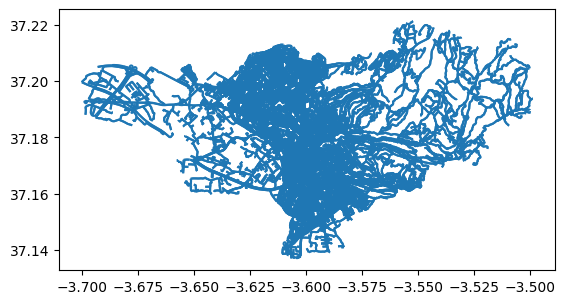

In [11]:
gdf_streets = gpd.read_file('Granada_POIs_streets.csv',GEOM_POSSIBLE_NAMES="geometry",
                            KEEP_GEOM_COLUMNS="NO", crs='EPSG:4326')
gdf_streets=gdf_streets.set_crs(epsg=4326, allow_override=True)
gdf_streets.plot()

Join both datasets `gdf_streets` and `gdf` to have a dataset of the road newtork with the associated zone unit each road belongs to

In [14]:
gdf_streets=gdf_streets.to_crs(epsg=25830)
roads_region=gpd.sjoin(gdf_streets, gdf,how="inner",predicate='intersects')
roads_region.rename(columns={"index_right": new_ind},inplace=True)
pop_size = gdf.loc[roads_region[new_ind].unique()]

We generate home locations along the road network using the road network `roads_region` and the population of each zone unit `pop_size[pop]`

In [15]:
import time
execution_times = []
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POI_houses = granada.create_houses_streets(roads_region.copy(),pop_size=pop_size['pop'],crs='EPSG:4326')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:387: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 1 completed in 8.1828 seconds.

Run 2/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:387: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 2 completed in 7.1175 seconds.

Run 3/10...


...

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 8 completed in 7.4074 seconds.

Run 9/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:387: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 9 completed in 8.6134 seconds.

Run 10/10...


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:360: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdk= gdf.groupby([index_col,'highway'])
/usr/local/lib/python3.12/dist-packages/spatialzosm/spatialize.py:387: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

Calculating random number of points per street type...
Calculating number of points per street...
Sampling points on streets...
Sampling completed. Coordinates saved to disk.
Run 10 completed in 7.2740 seconds.

--- Timing Results ---
Average computation time: 8.7790 seconds
Shortest computation time: 7.1175 seconds
Longest computation time: 12.6139 seconds


## Generating home locations within building geometries

To generate home locations along the road network, we need the geospatial information of the building shapes.
We can extract the road network from OSM using:

In [16]:
buildings=granada.fetch_osm_buildings()

Obtaining buildings from OSM for {'city': 'Granada', 'country': 'Spain'}. It can take a few minutes...
Filtering, cleaning and rearranging buildings for {'city': 'Granada', 'country': 'Spain'}.
 It can take a few minutes...
OSM buildings obtained successfully. File saved as Granada_POIs_buildings.csv


We read the obtained dataset

In [17]:
gdf_building = gpd.read_file('Granada_POIs_buildings.csv',GEOM_POSSIBLE_NAMES="geometry", KEEP_GEOM_COLUMNS="NO", crs='EPSG:4326')
gdf_building=gdf_building.set_crs(epsg=4326, allow_override=True)

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


We filter the dataset to obtain only buildings that can allocate homes

In [18]:
gdf_building['building']=gdf_building['building'].astype(str)
gdf_building=gdf_building[(gdf_building['building']=='yes') | (gdf_building['building']=='hotel')| (gdf_building['building']=='apartment')| (gdf_building['building']=='apartments')| (gdf_building['building']=='bungalow')| (gdf_building['building']=='cabin')| (gdf_building['building']=='dormitory')| (gdf_building['building']=='flats')| (gdf_building['building']=='house')|  (gdf_building['building']=='residential')| (gdf_building['building']=='boathouse')| (gdf_building['building']=='allotment_house')| (gdf_building['building']=='terrace')| (gdf_building['building']=='transformer_house')| (gdf_building['building']=='summer_house')| (gdf_building['building']=='houseboat')| (gdf_building['building']=='terrace')]
gdf_building=gdf_building[['building','geometry']]

Join both datasets `gdf_building` and `gdf` to have a dataset of the road newtork with the associated zone unit each road belongs to

In [19]:
gdf_building=gdf_building.to_crs(epsg=25830)
buildings_region=gpd.sjoin(gdf_building, gdf,how="left",predicate='within')
buildings_region.rename(columns={"index_right": new_ind},inplace=True)
buildings_region=buildings_region.dropna(subset=new_ind)
pop_size = gdf.loc[buildings_region[new_ind].unique()]

Generate the locations within the buildings. The generation is based on the types of buildings in **building** column of `buildings_region`

In [20]:
import time
execution_times = []
building_type_column = 'building'
runs = 10
for i in range(runs):
    print(f"\nRun {i+1}/{runs}...")
    start_time = time.time()
    POI_houses = granada.create_houses_buildings(buildings_region.copy(),pop_size=pop_size['pop'],index_column=new_ind,building_column=building_type_column,crs='EPSG:25830')
    end_time = time.time()
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"Run {i+1} completed in {elapsed_time:.4f} seconds.")

average_time = sum(execution_times) / len(execution_times)
shortest_time = min(execution_times)
longest_time = max(execution_times)

print("\n--- Timing Results ---")
print(f"Average computation time: {average_time:.4f} seconds")
print(f"Shortest computation time: {shortest_time:.4f} seconds")
print(f"Longest computation time: {longest_time:.4f} seconds")


Run 1/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 1 completed in 10.1768 seconds.

Run 2/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 2 completed in 10.1001 seconds.

Run 3/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 3 completed in 10.9595 seconds.

Run 4/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 4 completed in 9.1506 seconds.

Run 5/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.
Run 5 completed in 10.2111 seconds.

Run 6/10...
Calculating number of points per building...
Sampling points on buildings...
Sampling completed. Coordinates saved to disk.